## **Feature Importance** 

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import json


In [2]:
# Load preprocessed data
data = np.load("artifacts/dataset_prepared.npz", allow_pickle=True)

X_train = data["X_tab_train"]
X_val   = data["X_tab_val"]
X_test  = data["X_tab_test"]

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

# For more stable feature importance, train+val are combined
X = np.vstack([X_train, X_val])
y = np.concatenate([y_train, y_val])

# Load feature names
feat_names = json.load(open("artifacts/feature_names.json"))["tab"]

### 3. Feature Selection with Different Approaches

In this section, we apply various feature selection techniques to identify the most important features for predicting outcomes. This helps reduce overfitting, improve model interpretability, and enhance performance by focusing on the most relevant variables. We use methods like mutual information, permutation importance, and decision trees to gain different perspectives on feature relevance.


#### 3.1 Feature Selection by Mutual Information

In this step, we use mutual information to measure the dependency between each feature and the target variable. Mutual information quantifies how much information is gained about the outcome by knowing a particular feature, capturing both linear and non-linear relationships. We apply this method to all features to rank their importance based on how informative they are for predicting the outcome. Unlike other methods, mutual information directly measures the statistical dependency without relying on a model, providing insights into feature relevance regardless of the underlying predictive model.


Feature: cats__shockable_rhythm_False, Score: 0.081572
Feature: cats__shockable_rhythm_True, Score: 0.075003
Feature: cats__hospital_F, Score: 0.037589
Feature: cats__hospital_A, Score: 0.034409
Feature: cats__hospital_E, Score: 0.032363
Feature: rosc__rosc, Score: 0.020304
Feature: nums__age, Score: 0.019360
Feature: cats__sex_Male, Score: 0.017694
Feature: cats__sex_Female, Score: 0.017499
Feature: cats__ohca_Unknown, Score: 0.016867
Feature: cats__shockable_rhythm_Unknown, Score: 0.016488
Feature: cats__sex_nan, Score: 0.010876
Feature: cats__hospital_B, Score: 0.003958
Feature: cats__ttm_33.0, Score: 0.000528
Feature: cats__hospital_D, Score: 0.000000
Feature: cats__ohca_False, Score: 0.000000
Feature: cats__ohca_True, Score: 0.000000
Feature: cats__ttm_36.0, Score: 0.000000
Feature: cats__ttm_No TTM, Score: 0.000000


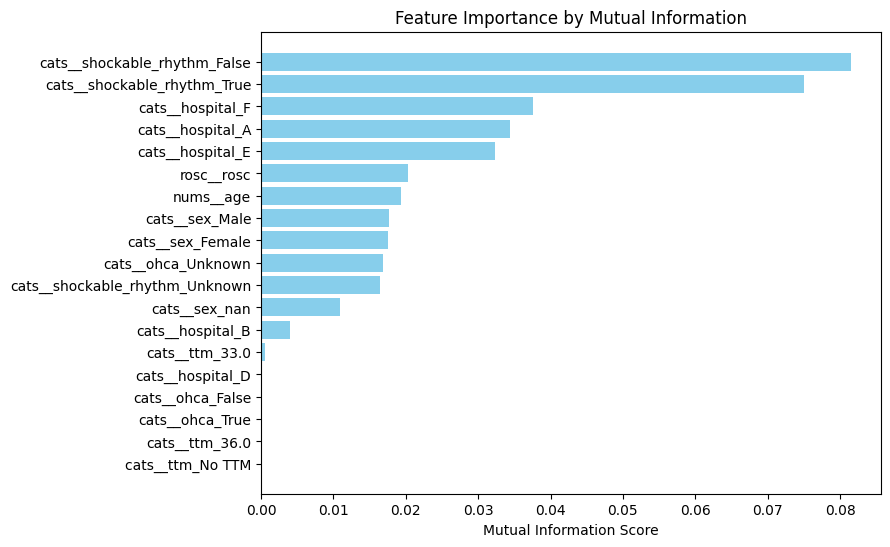

In [3]:
# Run mutual information
fs = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k="all")
fs.fit(X, y)

# Pair names with scores
feature_scores = list(zip(feat_names, fs.scores_))
feature_scores_sorted = sorted(feature_scores, key=lambda x: x[1], reverse=True)

# Print top features
for feature, score in feature_scores_sorted:
    print(f"Feature: {feature}, Score: {score:.6f}")

# Normalize for visualization
scaler = MinMaxScaler()
scores_normalized = scaler.fit_transform(np.array([s for _, s in feature_scores_sorted]).reshape(-1, 1)).flatten()

# Create dataframe
feature_scores_df = pd.DataFrame({
    "Feature": [f for f, _ in feature_scores_sorted],
    "Mutual Information": [s for _, s in feature_scores_sorted],
    "Normalized Score": scores_normalized
})

# Plot
plt.figure(figsize=(8,6))
plt.barh(feature_scores_df["Feature"], feature_scores_df["Mutual Information"], color="skyblue")
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance by Mutual Information")
plt.gca().invert_yaxis()
plt.show()


#### 3.2 Feature Selection by Random Forest

In this approach, we use a Random Forest model to evaluate feature importance based on how much each feature contributes to reducing impurity across the decision trees. Features are ranked according to how frequently and effectively they are used to split the data, providing insights into their relevance for making predictions. Unlike mutual information, Random Forest is a model-based method that takes feature interactions into account, making it useful for identifying features that are impactful within the context of tree-based models.


Accuracy: 0.6413043478260869
              precision    recall  f1-score   support

           0       0.70      0.76      0.73        58
           1       0.52      0.44      0.48        34

    accuracy                           0.64        92
   macro avg       0.61      0.60      0.60        92
weighted avg       0.63      0.64      0.63        92

Feature: nums__age, Score: 0.450900
Feature: rosc__rosc, Score: 0.156087
Feature: cats__shockable_rhythm_False, Score: 0.085370
Feature: cats__shockable_rhythm_True, Score: 0.084060
Feature: cats__sex_Female, Score: 0.023747
Feature: cats__sex_Male, Score: 0.022674
Feature: cats__hospital_A, Score: 0.019883
Feature: cats__ohca_False, Score: 0.019811
Feature: cats__ttm_33.0, Score: 0.017836
Feature: cats__ohca_True, Score: 0.017814
Feature: cats__hospital_D, Score: 0.015773
Feature: cats__hospital_E, Score: 0.015451
Feature: cats__hospital_B, Score: 0.014875
Feature: cats__hospital_F, Score: 0.013063
Feature: cats__ttm_36.0, Score: 0.011

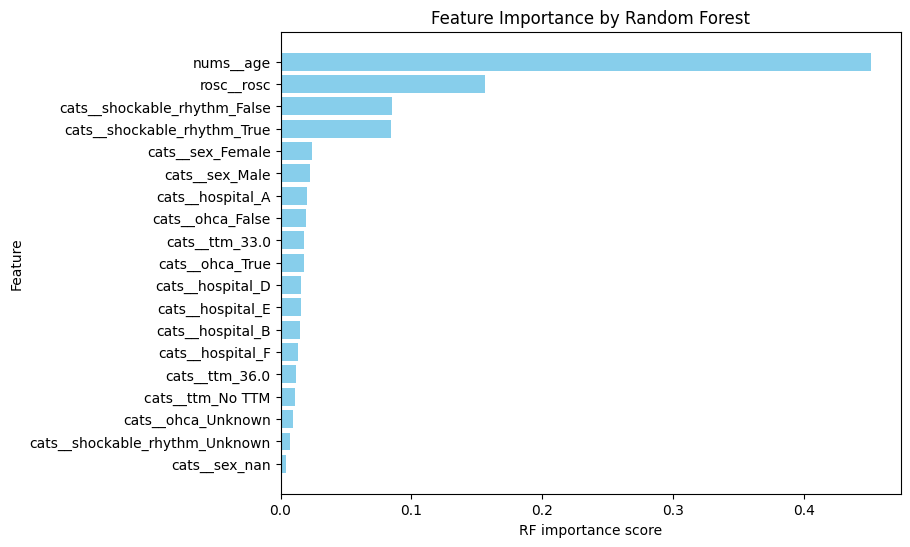

In [4]:
# --- Train Random Forest ---
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Evaluate on test set
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# --- Feature importance ---
importances = rf.feature_importances_
importance_scores = list(zip(feat_names, importances))
importance_scores_sorted = sorted(importance_scores, key=lambda x: x[1], reverse=True)

# Print results
for feature, score in importance_scores_sorted:
    print(f"Feature: {feature}, Score: {score:.6f}")

# --- Plot ---
features_names = [feature for feature, score in importance_scores_sorted]
features_scores = [score for feature, score in importance_scores_sorted]

plt.figure(figsize=(8,6))
plt.barh(features_names, features_scores, color='skyblue')
plt.xlabel('RF importance score')
plt.ylabel('Feature')
plt.title('Feature Importance by Random Forest')
plt.gca().invert_yaxis()
plt.show()

# --- Normalize scores for comparison with other methods ---
scaler = MinMaxScaler()
features_scores_normalized = scaler.fit_transform(np.array(features_scores).reshape(-1, 1)).flatten()

feature_scores_rf_df = pd.DataFrame({
    "Feature": features_names,
    "RF Importance": features_scores,
    "RF Normalized": features_scores_normalized
})

#### 3.3 Feature Selection by Permutation

In this approach, we use permutation feature importance to evaluate how each feature impacts the model's performance. By randomly shuffling the values of each feature and observing the resulting decrease in model accuracy, we determine the significance of that feature. Unlike other methods, permutation importance directly measures the impact of disrupting each feature on the model’s predictions, making it particularly useful for understanding feature contributions in the context of the trained model.


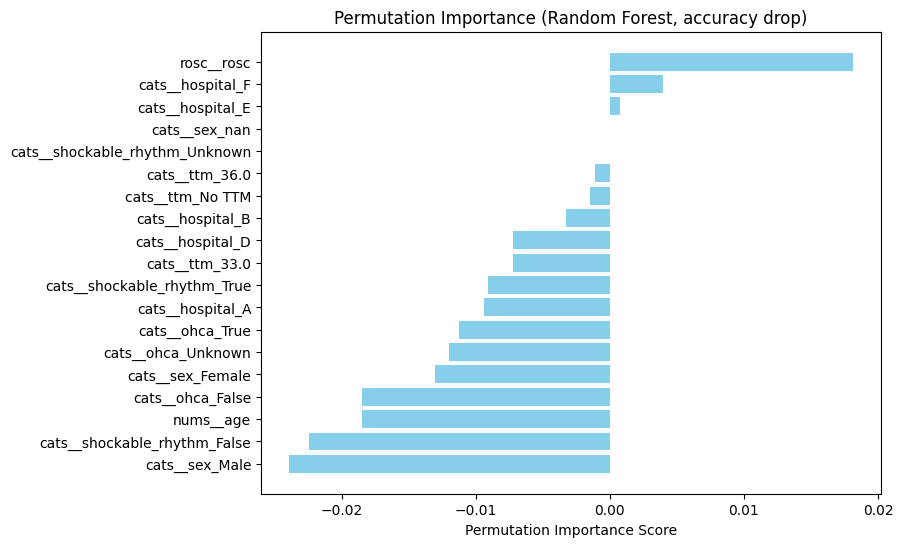

,Feature,Permutation Importance,Perm Normalized
0,rosc__rosc,1.811594e-02,1.000000
1,cats__hospital_F,3.985507e-03,0.663793
2,cats__hospital_E,7.246377e-04,0.586207
3,cats__sex_nan,0.000000e+00,0.568966
4,cats__shockable_rhythm_Unknown,-3.700743e-18,0.568966
5,cats__ttm_36.0,-1.086957e-03,0.543103
6,cats__ttm_No TTM,-1.449275e-03,0.534483
7,cats__hospital_B,-3.260870e-03,0.491379
8,cats__hospital_D,-7.246377e-03,0.396552
9,cats__ttm_33.0,-7.246377e-03,0.396552


In [5]:
# ---- Run permutation importance on TEST ----
results = permutation_importance(rf, X_test, y_test, scoring="accuracy", n_repeats=30, random_state=42)

perm_importance = results.importances_mean
assert len(feat_names) == len(perm_importance)

# ---- Build DataFrame ----
perm_df = (pd.DataFrame({"Feature": feat_names, "Permutation Importance": perm_importance})
             .sort_values("Permutation Importance", ascending=False)
             .reset_index(drop=True))

# Normalize
perm_df["Perm Normalized"] = MinMaxScaler().fit_transform(
    perm_df[["Permutation Importance"]]
)

# ---- Plot ----
plt.figure(figsize=(8, 6))
plt.barh(perm_df["Feature"], perm_df["Permutation Importance"], color="skyblue")
plt.xlabel("Permutation Importance Score")
plt.title("Permutation Importance (Random Forest, accuracy drop)")
plt.gca().invert_yaxis()
plt.show()

perm_df.head(20)


#### 3.4 Overall Feature Importance Analysis

In this step, we combine the **normalized feature importance scores** from the three different feature selection methods: **Mutual Information**, **Random Forest**, and **Permutation Importance**. By aggregating the scores from multiple methods, we gain a comprehensive understanding of the significance of each feature. This approach helps us identify which features consistently contribute to model performance across different perspectives, allowing for more robust feature selection.


In [6]:
# --- unify column names ---
mi_df   = feature_scores_df[["Feature", "Normalized Score"]].rename(
    columns={"Normalized Score": "MI"}
)

rf_df   = feature_scores_rf_df[["Feature", "RF Normalized"]].rename(
    columns={"RF Normalized": "RF"}
)

perm_df = perm_df[["Feature", "Perm Normalized"]].rename(
    columns={"Perm Normalized": "Perm"}
)

# --- merge (outer, to be safe) ---
combined_df = (
    mi_df.merge(rf_df, on="Feature", how="outer")
         .merge(perm_df, on="Feature", how="outer")
)

# any feature missing in a method -> 0
combined_df[["MI","RF","Perm"]] = combined_df[["MI","RF","Perm"]].fillna(0.0)

# --- aggregate & rank ---
combined_df["Total Importance"] = combined_df[["MI","RF","Perm"]].sum(axis=1)

# optional: consensus rank (lower is better)
combined_df["Rank_MI"]   = combined_df["MI"].rank(ascending=False, method="average")
combined_df["Rank_RF"]   = combined_df["RF"].rank(ascending=False, method="average")
combined_df["Rank_Perm"] = combined_df["Perm"].rank(ascending=False, method="average")
combined_df["Consensus Rank"] = combined_df[["Rank_MI","Rank_RF","Rank_Perm"]].mean(axis=1)

# --- final sorted views ---
combined_by_total = combined_df.sort_values("Total Importance", ascending=False).reset_index(drop=True)
combined_by_rank  = combined_df.sort_values("Consensus Rank", ascending=True).reset_index(drop=True)


In [7]:
print("Top by Total Importance")
combined_by_total.head(15)

Top by Total Importance


,Feature,MI,RF,Perm,Total Importance,Rank_MI,Rank_RF,Rank_Perm,Consensus Rank
0,rosc__rosc,0.248911,0.340162,1.000000,1.589073,6.0,2.0,1.0,3.000000
1,cats__shockable_rhythm_True,0.919474,0.178955,0.353448,1.451877,2.0,4.0,11.0,5.666667
2,nums__age,0.237335,1.000000,0.129310,1.366645,7.0,1.0,17.0,8.333333
3,cats__shockable_rhythm_False,1.000000,0.181886,0.034483,1.216369,1.0,3.0,18.0,7.333333
4,cats__hospital_F,0.460814,0.020052,0.663793,1.144660,3.0,14.0,2.0,6.333333
5,cats__hospital_E,0.396742,0.025396,0.586207,1.008345,5.0,12.0,3.0,6.666667
6,cats__hospital_A,0.421825,0.035316,0.344828,0.801969,4.0,7.0,12.0,7.666667
7,cats__shockable_rhythm_Unknown,0.202125,0.006842,0.568966,0.777933,11.0,18.0,5.0,11.333333
8,cats__sex_nan,0.133337,0.000000,0.568966,0.702302,12.0,19.0,4.0,11.666667
9,cats__hospital_B,0.048522,0.024107,0.491379,0.564008,13.0,13.0,8.0,11.333333


In [8]:
print("\nTop by Consensus Rank")
combined_by_rank.head(15)


Top by Consensus Rank


,Feature,MI,RF,Perm,Total Importance,Rank_MI,Rank_RF,Rank_Perm,Consensus Rank
0,rosc__rosc,0.248911,0.340162,1.000000,1.589073,6.0,2.0,1.0,3.000000
1,cats__shockable_rhythm_True,0.919474,0.178955,0.353448,1.451877,2.0,4.0,11.0,5.666667
2,cats__hospital_F,0.460814,0.020052,0.663793,1.144660,3.0,14.0,2.0,6.333333
3,cats__hospital_E,0.396742,0.025396,0.586207,1.008345,5.0,12.0,3.0,6.666667
4,cats__shockable_rhythm_False,1.000000,0.181886,0.034483,1.216369,1.0,3.0,18.0,7.333333
5,cats__hospital_A,0.421825,0.035316,0.344828,0.801969,4.0,7.0,12.0,7.666667
6,nums__age,0.237335,1.000000,0.129310,1.366645,7.0,1.0,17.0,8.333333
7,cats__sex_Female,0.214522,0.043963,0.258621,0.517106,9.0,5.0,15.0,9.666667
8,cats__ttm_33.0,0.006473,0.030734,0.396552,0.433759,14.0,9.0,9.5,10.833333
9,cats__sex_Male,0.216917,0.041562,0.000000,0.258479,8.0,6.0,19.0,11.000000


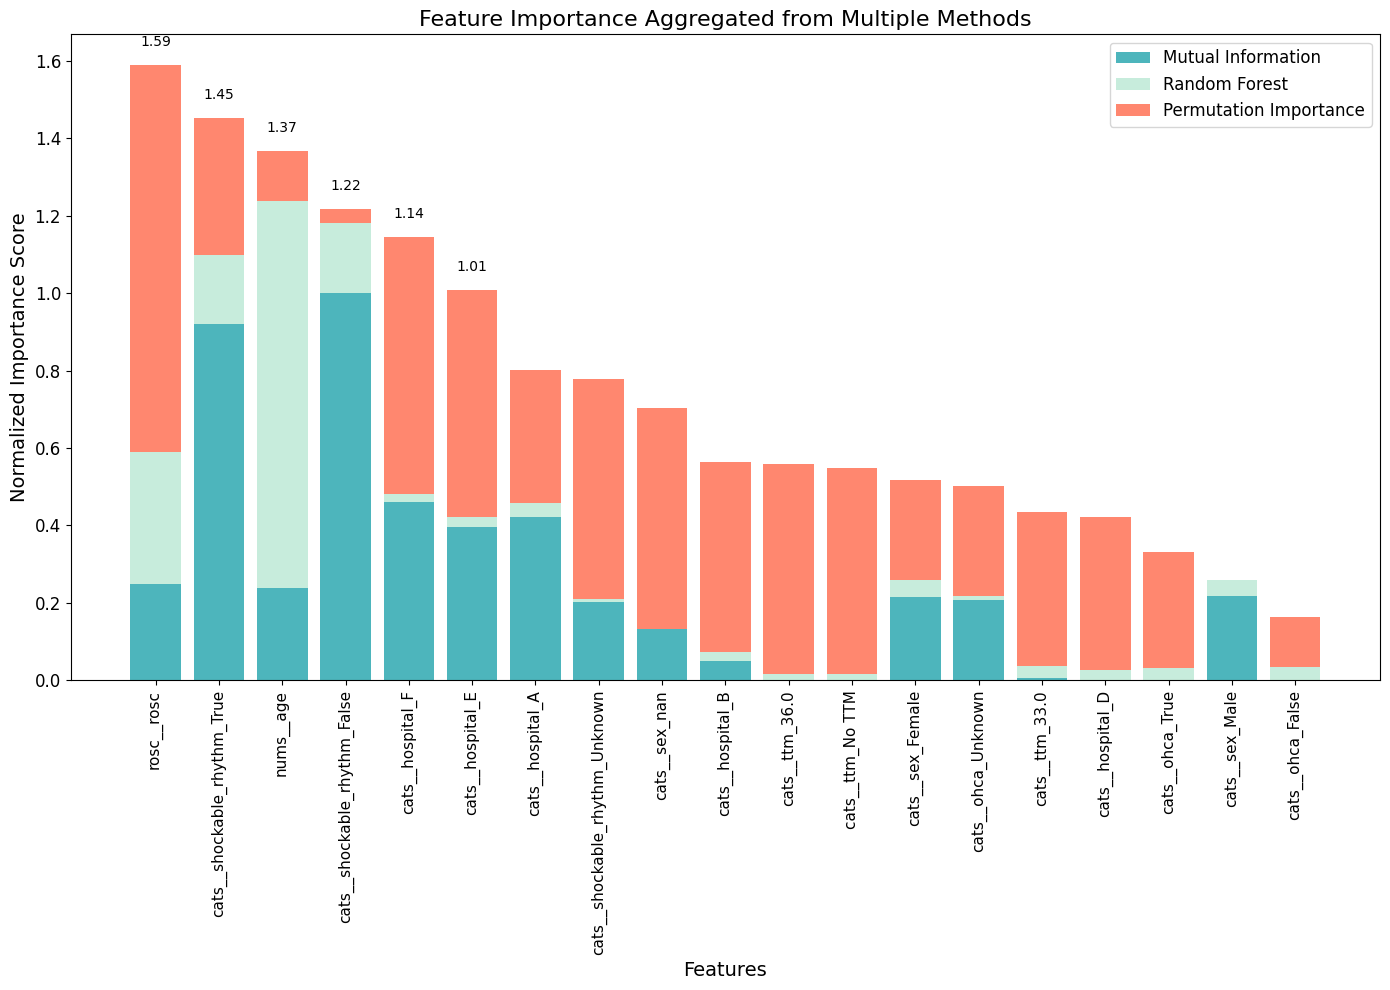

In [9]:
# --- Karolinska Institutet colors ---
KI_COLORS = {
    "MI": "#4DB5BC",    # Blue
    "RF": "#C7ECDC",    # Light Green
    "Perm": "#FF876F"   # Salmon/Orange
}

# --- Select features & scores from combined table ---
features    = combined_by_total["Feature"]
mi_scores   = combined_by_total["MI"]
rf_scores   = combined_by_total["RF"]
perm_scores = combined_by_total["Perm"]
totals      = combined_by_total["Total Importance"]

# --- Plot stacked bar chart ---
plt.figure(figsize=(14, 10))

plt.bar(
    features, 
    mi_scores, 
    label="Mutual Information", 
    color=KI_COLORS["MI"]
)
plt.bar(
    features, 
    rf_scores, 
    bottom=mi_scores, 
    label="Random Forest", 
    color=KI_COLORS["RF"]
)
plt.bar(
    features, 
    perm_scores, 
    bottom=mi_scores + rf_scores, 
    label="Permutation Importance", 
    color=KI_COLORS["Perm"]
)

# --- Formatting ---
plt.xlabel("Features", fontsize=14)
plt.ylabel("Normalized Importance Score", fontsize=14)
plt.title("Feature Importance Aggregated from Multiple Methods", fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=12)
plt.legend(loc="upper right", fontsize=12)
plt.tight_layout()

# --- Annotate only top features ---
for idx, value in enumerate(totals):
    if value > 1.0:   # adjust threshold for your data
        plt.text(idx, value + 0.05, f"{value:.2f}", 
                 ha="center", fontsize=10, color="black")

# --- Save both transparent + white background ---
plt.savefig("graphics/feature_importance_transparent.svg", format="svg", transparent=True)
plt.savefig("graphics/feature_importance_white.svg", format="svg", transparent=False)

plt.show()


### Summary of Feature Importance Analysis

The feature importance scores were aggregated from three different methods: **Mutual Information**, **Random Forest**, and **Permutation Importance**. The aim was to identify which features consistently influence the target outcome and to compare the results across different methodologies.  

#### Key Insights:

1. **Most Important Features**:
   - The **`rosc`** (Return of Spontaneous Circulation) feature emerged as the most important predictor overall.  
     - It ranked **highest in permutation importance** and also scored strongly in Random Forest, confirming its central role in predicting outcomes.  
     - In Mutual Information it contributed less compared to other features, which may reflect how MI handles continuous distributions after scaling, but its overall dominance across methods underscores its clinical and statistical significance.  
   - **`age`** also proved influential, being the top-ranked feature in Random Forest and showing moderate contributions in Mutual Information and permutation importance.  

2. **Moderately Important Features**:
   - **Shockable Rhythm** (`cats__shockable_rhythm_True` and `cats__shockable_rhythm_False`) showed strong importance under Mutual Information and reasonable relevance in Random Forest, though less so in permutation. This suggests it carries predictive signal, but its impact may vary depending on how the feature selection method evaluates conditional dependencies.  
   - **Hospital identifiers** (`hospital_E`, `hospital_F`, `hospital_A`) were consistently ranked in the mid-range, especially in permutation importance. This pattern may reflect institutional or cohort-specific effects rather than direct clinical drivers of outcome.  

3. **Least Important Features**:
   - Several features, including **unknown or missing values** (`shockable_rhythm_Unknown`, `sex_nan`, `ohca_Unknown`) and some **TTM-related indicators** (`ttm_33.0`, `ttm_36.0`, `ttm_No TTM`), ranked lower across most methods.  
   - While TTM features gained some weight in permutation importance, they showed limited impact in Mutual Information and Random Forest, suggesting their predictive contribution is less consistent in this dataset.  
